In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('Titanic.csv', usecols = ['Age', 'Fare', 'Survived'])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [8]:
df['Age'].fillna(df['Age'].mean())

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [9]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
x = df.iloc[:, 1:3]
y = df.iloc[:, 0]

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

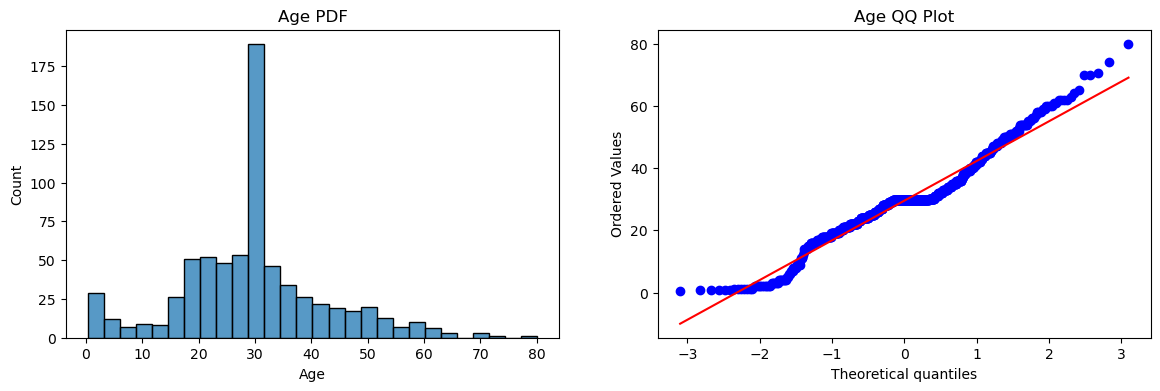

In [23]:
plt.figure(figsize = (14, 4))
plt.subplot(121)
sns.histplot(x_train['Age'])   #displot() earlier
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'], dist = 'norm', plot = plt)
plt.title('Age QQ Plot')
plt.show()

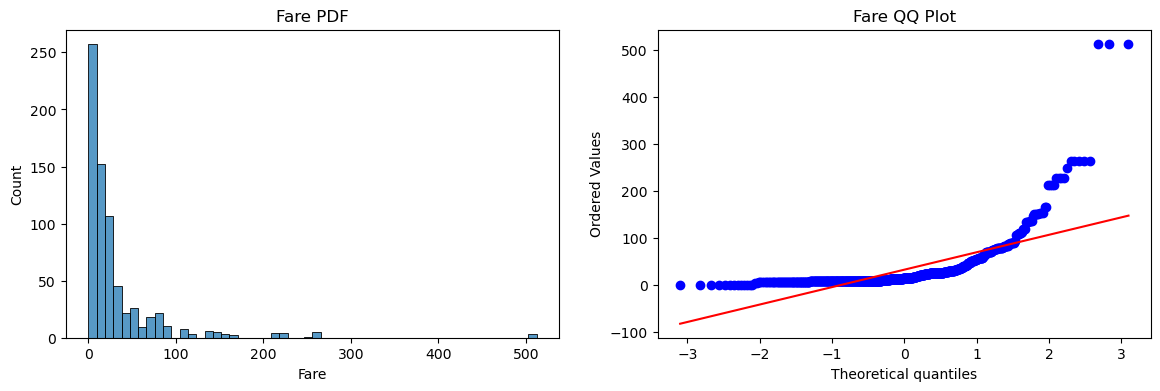

In [27]:
plt.figure(figsize = (14, 4))
plt.subplot(121)
sns.histplot(x_train['Fare'])   #displot() earlier
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'], dist = 'norm', plot = plt)
plt.title('Fare QQ Plot')
plt.show()

#FAre is right skewed

In [28]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [29]:
clf.fit(x_train, y_train)
clf2.fit(x_train, y_train)

y_pred = clf.predict(x_test)
y_pred2= clf2.predict(x_test)

print('Accuracy of LR: ', accuracy_score(y_test, y_pred))
print('Accuracy of DT: ', accuracy_score(y_test, y_pred2))

Accuracy of LR:  0.6480446927374302
Accuracy of DT:  0.664804469273743


In [32]:
#applying l

trf = FunctionTransformer(func = np.log1p)
#we can use np.logp, but log(0) is undefined
#so we use np.log1p(), it adds +1 to the value to avoid undefined error

In [37]:
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.transform(x_test)

In [38]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [39]:
clf.fit(x_train_transformed, y_train)
clf2.fit(x_train_transformed, y_train)

y_pred = clf.predict(x_test_transformed)
y_pred2= clf2.predict(x_test_transformed)

print('Accuracy of LR: ', accuracy_score(y_test, y_pred))
print('Accuracy of DT: ', accuracy_score(y_test, y_pred2))

Accuracy of LR:  0.6815642458100558
Accuracy of DT:  0.6759776536312849


In [40]:
#accuracy of LR changed significantly

In [42]:
#cross validation score (10 baar train test split and then finding mean)
x_transform = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, x_transform, y, scoring = 'accuracy', cv = 10)))
print("DT", np.mean(cross_val_score(clf2, x_transform, y, scoring = 'accuracy', cv = 10)))

LR 0.678027465667915
DT 0.6610611735330837


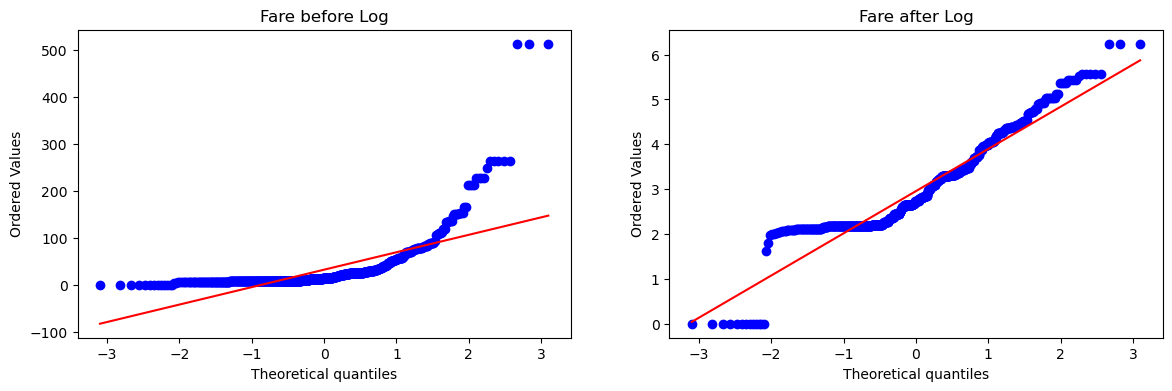

In [44]:
#fare qqplot before and after log transformation
plt.figure(figsize = (14, 4))

plt.subplot(121)
stats.probplot(x_train['Fare'], dist = 'norm', plot = plt)
plt.title('Fare before Log')

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'], dist = 'norm', plot = plt)
plt.title('Fare after Log')
plt.show()

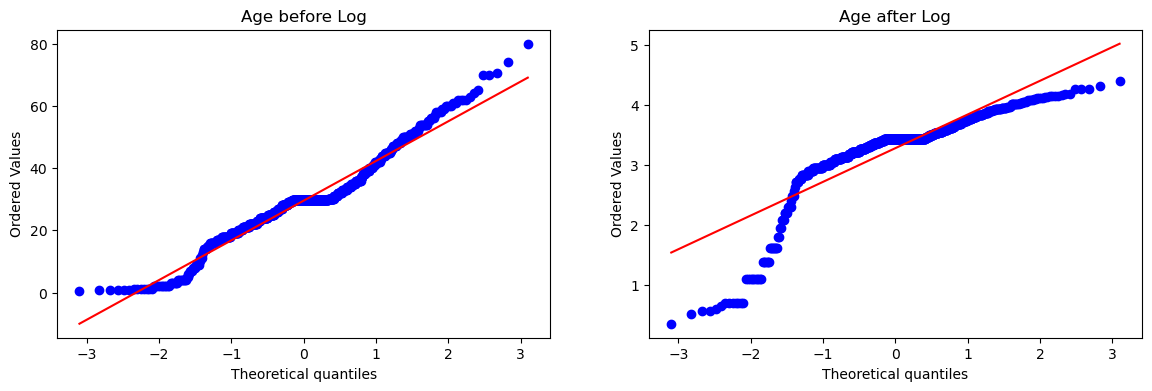

In [45]:
#age qqplot before and after log transformation
plt.figure(figsize = (14, 4))

plt.subplot(121)
stats.probplot(x_train['Age'], dist = 'norm', plot = plt)
plt.title('Age before Log')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'], dist = 'norm', plot = plt)
plt.title('Age after Log')
plt.show()

#age gets distorted

In [49]:
#applying column transformation to apply transformation only on fare

trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

x_train_transformed2 = trf2.fit_transform(x_train)
x_test_transformed2 = trf2.transform(x_test)

In [51]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train_transformed2,y_train)
clf2.fit(x_train_transformed2,y_train)
    
y_pred = clf.predict(x_test_transformed2)
y_pred2 = clf2.predict(x_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6759776536312849
